In [1]:
RANDOM_SEED = 231216143

In [2]:
from two_player_games.player import Player
from typing import Optional
import math
import random
from two_player_games.games.isolation import Isolation, IsolationMove, IsolationState
from enum import Enum

class EvaluationFunction(Enum):
    FULL = "FULL"
    SIMPLE = "SIMPLE"

class IsolationAI:
    def __init__(self, player: Player, depth: int) -> None:
        self.player = player
        self.depth = depth

    def evaluate(self, state: IsolationState) -> float:
        if state.is_finished():
            winner = state.get_winner()
            if winner == self.player:
                return 10000
            elif winner is None:
                return 0
            else:
                return -10000

        player = self.player
        opponent = state.other_player if state.current_player == player else state.current_player

        player_moves = len(list(state.get_moves_for_player(self.player)))
        opponent_moves = len(list(state.get_moves_for_player(opponent)))

        player_pos = state.current_positions[self.player]
        opponent_pos = state.current_positions[opponent]

        def center_score(pos):
            row, col = pos // state.size, pos % state.size
            center = (state.size - 1) / 2
            return -((row - center)**2 + (col - center)**2)

        return (
            3 * (player_moves - opponent_moves)
            + .3 * (center_score(player_pos) - center_score(opponent_pos))
        )

    def evaluate_simple(self, state: IsolationState) -> int:
        if state.is_finished():
            winner = state.get_winner()
            if winner == self.player:
                return 1_000
            elif winner is None:
                return 0
            else:
                return -1_000

        player_moves = len(list(state.get_moves_for_player(self.player)))

        opponent = state.other_player if state.current_player == self.player else state.current_player
        opponent_moves = len(list(state.get_moves_for_player(opponent)))

        return 2 * player_moves - opponent_moves

    def minimax_with_pruning(
            self,
            state: IsolationState,
            depth: int,
            alpha: int,
            beta: int,
            evaluation_function: EvaluationFunction = EvaluationFunction.FULL
        ):
        evaluate = self.evaluate if evaluation_function == EvaluationFunction.FULL else self.evaluate_simple
        if depth == 0 or state.is_finished():
            return evaluate(state), None

        is_max = (state.current_player == self.player)

        best_move = None
        best_val = -math.inf if is_max else math.inf

        moves = list(state.get_moves())

        for move in moves:
            new_state = state.make_move(move)

            val, _ = self.minimax_with_pruning(new_state, depth - 1, alpha, beta, evaluation_function)

            if is_max:
                if val > best_val:
                    best_val = val
                    best_move = move
                alpha = max(alpha, val)
            else:
                if val < best_val:
                    best_val = val
                    best_move = move
                beta = min(beta, val)

            if beta <= alpha:
                break

        return best_val, best_move

    def choose_move(self, state: IsolationState, evaluation_function: EvaluationFunction = EvaluationFunction.FULL) -> Optional[IsolationMove]:
        _, move = self.minimax_with_pruning(
            state=state,
            depth=self.depth,
            alpha=-math.inf,
            beta=math.inf,
            evaluation_function=evaluation_function
        )
        return move

In [3]:
from typing import cast

game = Isolation(size=3)
state: IsolationState = cast(IsolationState, game.state)
ai = IsolationAI(player=state.current_player, depth=5)

while not state.is_finished():
    print(state)
    move = ai.choose_move(state)
    if move:
        print(f"AI chooses: {move.field}")
        state = state.make_move(move)
print(state)


[O]| 1 | 2 
-----------
 3 | 4 | 5 
-----------
 6 | 7 |[X]

Current player: O
AI chooses: 4

 O | 1 | 2 
-----------
 3 |[O]| 5 
-----------
 6 | 7 |[X]

Current player: X
AI chooses: 5

 O | 1 | 2 
-----------
 3 |[O]|[X]
-----------
 6 | 7 | X 

Current player: O
AI chooses: 3

 O | 1 | 2 
-----------
[O]| O |[X]
-----------
 6 | 7 | X 

Current player: X
AI chooses: 1

 O |[X]| 2 
-----------
[O]| O | X 
-----------
 6 | 7 | X 

Current player: O
AI chooses: 6

 O |[X]| 2 
-----------
 O | O | X 
-----------
[O]| 7 | X 

Current player: X
AI chooses: 2

 O | X |[X]
-----------
 O | O | X 
-----------
[O]| 7 | X 

Current player: O
AI chooses: 7

 O | X |[X]
-----------
 O | O | X 
-----------
 O |[O]| X 

Winner: Player O


In [4]:
class IsolationRunner:
    def __init__(
        self,
        size: int = 5,
        human_player: Optional[Player] = None,
        ai_depth: Optional[int] = None,
        ai_depths: Optional[tuple[int, int]] = None,
        random_beginning: bool = False
    ):
        self.human_player = human_player
        self.ai1: Optional[IsolationAI] = None
        self.ai2: Optional[IsolationAI] = None

        # AI vs human
        if human_player and ai_depth is not None:
            ai_player = Player("X")
            first, second = human_player, ai_player

            self.ai1 = IsolationAI(ai_player, depth=ai_depth)

        # AI vs AI
        elif ai_depths is not None:
            depth1, depth2 = ai_depths

            first = Player("O")
            second = Player("X")

            self.ai1 = IsolationAI(first, depth=depth1)
            self.ai2 = IsolationAI(second, depth=depth2)

        else:
            first = Player("O")
            second = Player("X")

        # random swap
        if random_beginning and random.choice([True, False]):
            first, second = second, first

        self.first_player = first
        self.second_player = second

        self.game = Isolation(size=size, first_player=first, second_player=second)
        self.state = self.game.state

    def play(
        self,
        do_prints: bool = True,
        print_last: bool = False,
        evaluation_function: EvaluationFunction = EvaluationFunction.FULL
    ):
        while not self.state.is_finished():
            if do_prints:
                print(self.state)

            current_player = self.state.current_player
            move = None

            # human
            if self.human_player and current_player == self.human_player:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves and do_prints:
                            print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return None
                        if do_prints:
                            print("Enter a valid number.")

            # ai1
            elif self.ai1 and current_player == self.ai1.player:
                move = self.ai1.choose_move(self.state, evaluation_function)
                assert move
                if do_prints:
                    print(f"AI1 (depth: {self.ai1.depth}) ({current_player.char}) chooses: {move.field}")

            # ai2
            elif self.ai2 and current_player == self.ai2.player:
                move = self.ai2.choose_move(self.state, evaluation_function)
                assert move
                if do_prints:
                    print(f"AI2 (depth: {self.ai2.depth}) ({current_player.char}) chooses: {move.field}")

            # human vs human
            else:
                moves = list(self.state.get_moves())
                while move not in moves:
                    inp = input(f"Available moves {[m.field for m in moves]}. Enter move for {current_player.char}: ")
                    try:
                        move_input = int(inp)
                        move = IsolationMove(move_input)
                        if move not in moves:
                            print("Invalid move. Try again.")
                    except ValueError:
                        if "x" in str(inp):
                            return None
                        print("Enter a valid number.")

            assert move
            self.state = self.state.make_move(move)

        if do_prints or print_last:
            print(self.state)

        winner = self.state.get_winner()

        if winner is None:
            return None

        if self.ai1 and winner == self.ai1.player:
            return 0

        if self.ai2 and winner == self.ai2.player:
            return 1

        if self.human_player:
            if winner == self.human_player:
                return 0
            else:
                return 1

        return None

In [16]:
human = Player("O")
runner = IsolationRunner(
    size=5,
    human_player=human,
    ai_depth=10
)
runner.play()


[O]| 1 | 2 | 3 | 4 
-------------------
 5 | 6 | 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |18 |19 
-------------------
20 |21 |22 |23 |[X]

Current player: O

 O | 1 | 2 | 3 | 4 
-------------------
 5 |[O]| 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |18 |19 
-------------------
20 |21 |22 |23 |[X]

Current player: X
AI1 (depth: 10) (X) chooses: 19

 O | 1 | 2 | 3 | 4 
-------------------
 5 |[O]| 7 | 8 | 9 
-------------------
10 |11 |12 |13 |14 
-------------------
15 |16 |17 |18 |[X]
-------------------
20 |21 |22 |23 | X 

Current player: O

 O | 1 | 2 | 3 | 4 
-------------------
 5 | O | 7 | 8 | 9 
-------------------
10 |11 |[O]|13 |14 
-------------------
15 |16 |17 |18 |[X]
-------------------
20 |21 |22 |23 | X 

Current player: X
AI1 (depth: 10) (X) chooses: 13

 O | 1 | 2 | 3 | 4 
-------------------
 5 | O | 7 | 8 | 9 
-------------------
10 |11 |[O]|[X]|14 
-------------------
15 |16 |17 |18 

0

In [17]:
runner = IsolationRunner(
    size=6,
    ai_depths=(2, 8)
)
runner.play(False, True, EvaluationFunction.FULL)


 O | 1 | 2 | 3 | 4 | 5 
-----------------------
[X]| O | X | O | O |11 
-----------------------
 X | X | O | X | O |17 
-----------------------
 X |[O]| X | X | O |23 
-----------------------
 O | X | X | O | X |29 
-----------------------
30 | O | O |33 |34 | X 

Winner: Player X


1

In [18]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from typing import Any

class IsolationMultiSim:
    def __init__(self, size: int = 5):
        self.size = size
        self.results = []

    def run_duel(
        self,
        depth_pair: tuple[int, int],
        n_games: int = 50,
        random_beginning: bool = True,
        evaluation_function: EvaluationFunction = EvaluationFunction.FULL
    ):
        depth1, depth2 = depth_pair
        wins_ai1 = 0
        wins_ai2 = 0

        for _ in tqdm(range(n_games), desc=f"Depth {depth1} vs {depth2}"):
            runner = IsolationRunner(
                size=self.size,
                ai_depths=(depth1, depth2),
                random_beginning=random_beginning
            )
            result = runner.play(do_prints=False, print_last=False, evaluation_function=evaluation_function)
            if result == 0:
                wins_ai1 += 1
            elif result == 1:
                wins_ai2 += 1

        duel_result = {
            "depth_pair": depth_pair,
            "wins_ai1": wins_ai1,
            "wins_ai2": wins_ai2,
            "difference": wins_ai1 - wins_ai2,
            "total_games": wins_ai1 + wins_ai2
        }

        self.results.append(duel_result)
        return duel_result

    def plot_duel_result(self, duel_result: dict[str, Any], evaluation_function: EvaluationFunction = EvaluationFunction.FULL):
        depth1, depth2 = duel_result["depth_pair"]
        wins_ai1 = duel_result["wins_ai1"]
        wins_ai2 = duel_result["wins_ai2"]
        difference = duel_result["difference"]
        total_games = duel_result["total_games"]

        x = [0]
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.bar(x, [total_games], color="lightgray", alpha=0.3, label="Total games")
        ax.bar(x, [-total_games], color="lightgray", alpha=0.3)
        ax.bar(x, [wins_ai1], color="green", alpha=0.7, label="AI1 wins")
        ax.bar(x, [-wins_ai2], color="red", alpha=0.7, label="AI2 wins")
        ax.scatter(x, [difference], color="blue", s=120, zorder=5, label="Difference (AI1-AI2)")
        ax.set_xticks([0])
        ax.set_xticklabels([f"{depth1}v{depth2}"])
        ax.set_ylim(-total_games, total_games)
        ax.set_ylabel("Games")
        ax.set_title(f"Isolation AI Duel: Depth {depth1} vs {depth2}, {evaluation_function}")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        plt.show()

Depth 6 vs 3: 100%|██████████| 100/100 [00:06<00:00, 15.45it/s]


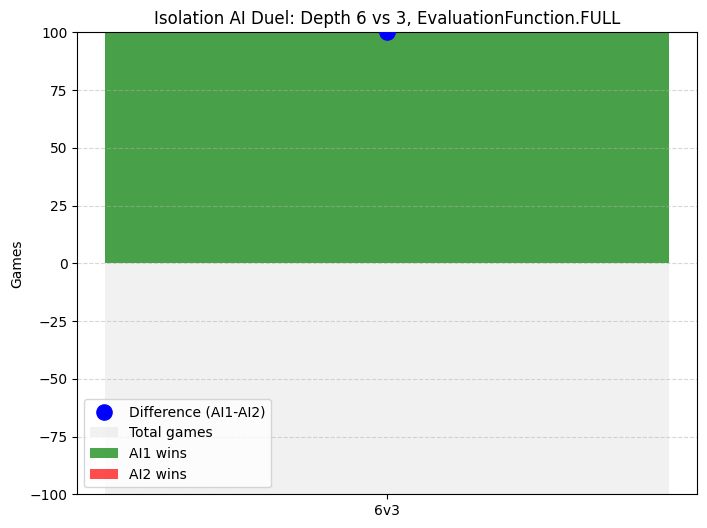

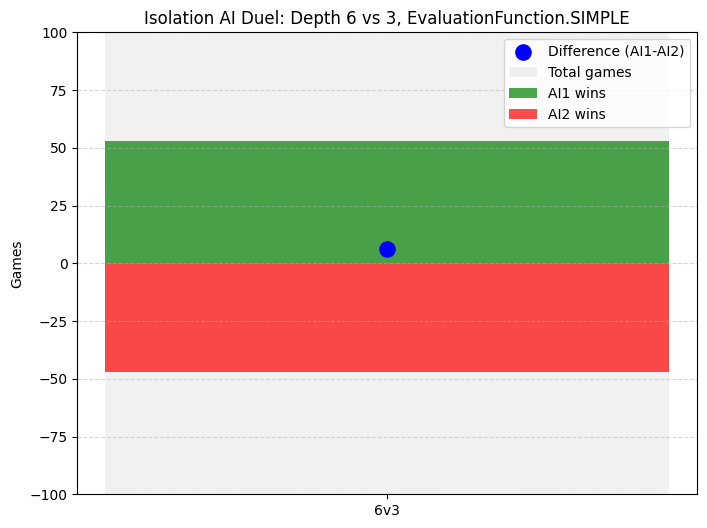

In [19]:
sim = IsolationMultiSim(size=5)
results_full = sim.run_duel((6, 3), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((6, 3), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE)

Depth 8 vs 2: 100%|██████████| 100/100 [00:24<00:00,  4.16it/s]


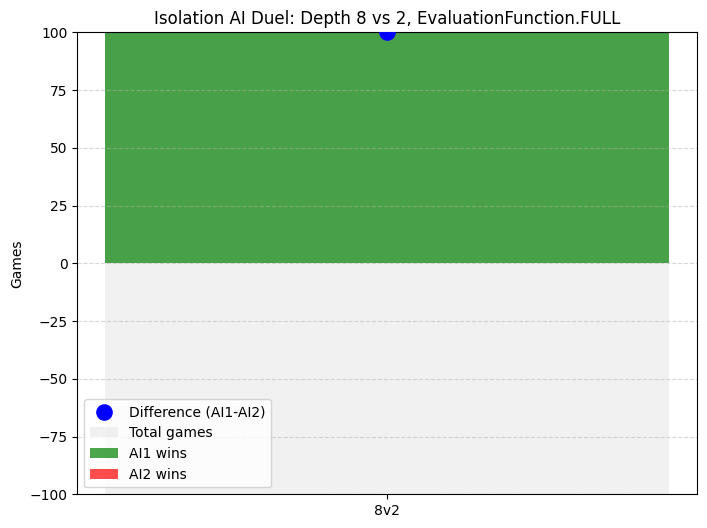

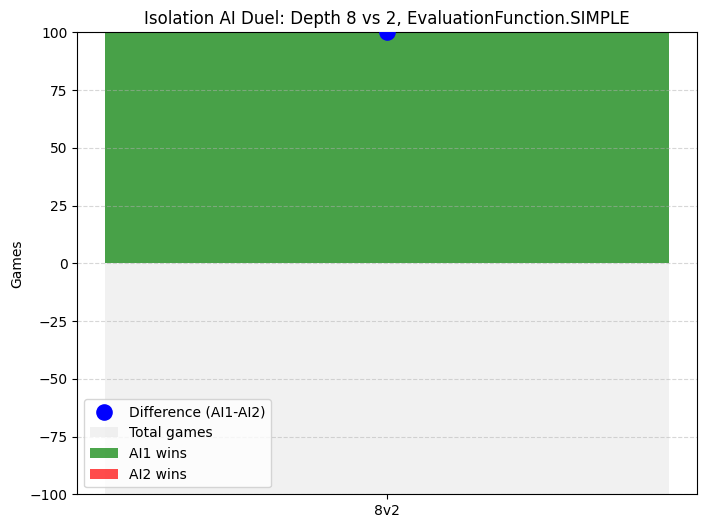

In [ ]:
sim = IsolationMultiSim(size=5)
results_full = sim.run_duel((8, 2), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((8, 2), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE)

Depth 10 vs 5: 100%|██████████| 100/100 [06:21<00:00,  3.81s/it]


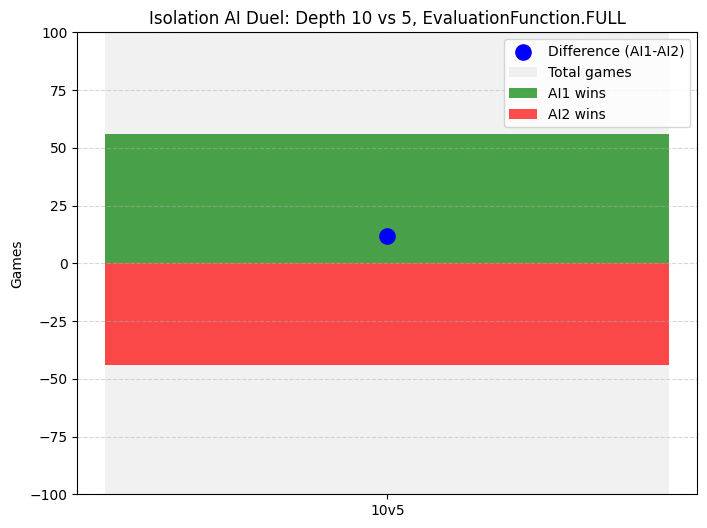

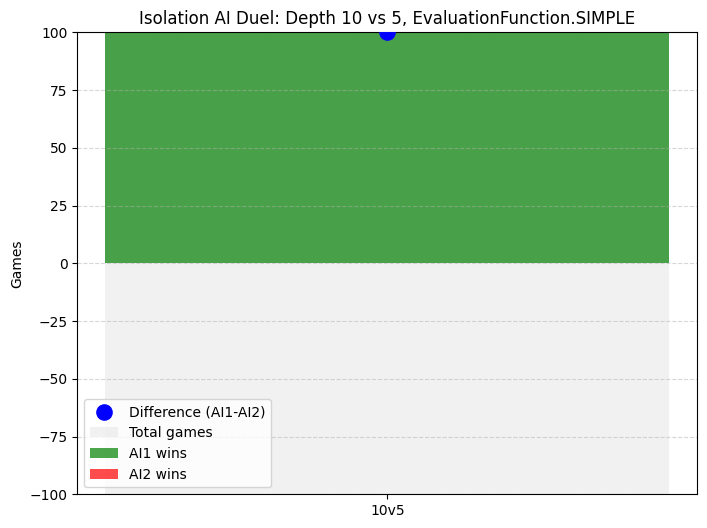

In [25]:
sim = IsolationMultiSim(size=6)
results_full = sim.run_duel((10, 5), n_games=100, evaluation_function=EvaluationFunction.FULL)
results_simple = sim.run_duel((10, 5), n_games=100, evaluation_function=EvaluationFunction.SIMPLE)
sim.plot_duel_result(results_full, evaluation_function=EvaluationFunction.FULL)
sim.plot_duel_result(results_simple, evaluation_function=EvaluationFunction.SIMPLE)